## New House Price Prediction

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [145]:
df = pd.read_csv("data.csv")
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [146]:
print(df['sqft_living'].max())
print(df['sqft_living'].min())

13540
370


In [147]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [148]:
print(df['price'].max())
print(df['price'].min())

26590000.0
0.0


Text(0.5, 1.0, 'yr_renovated VS Price')

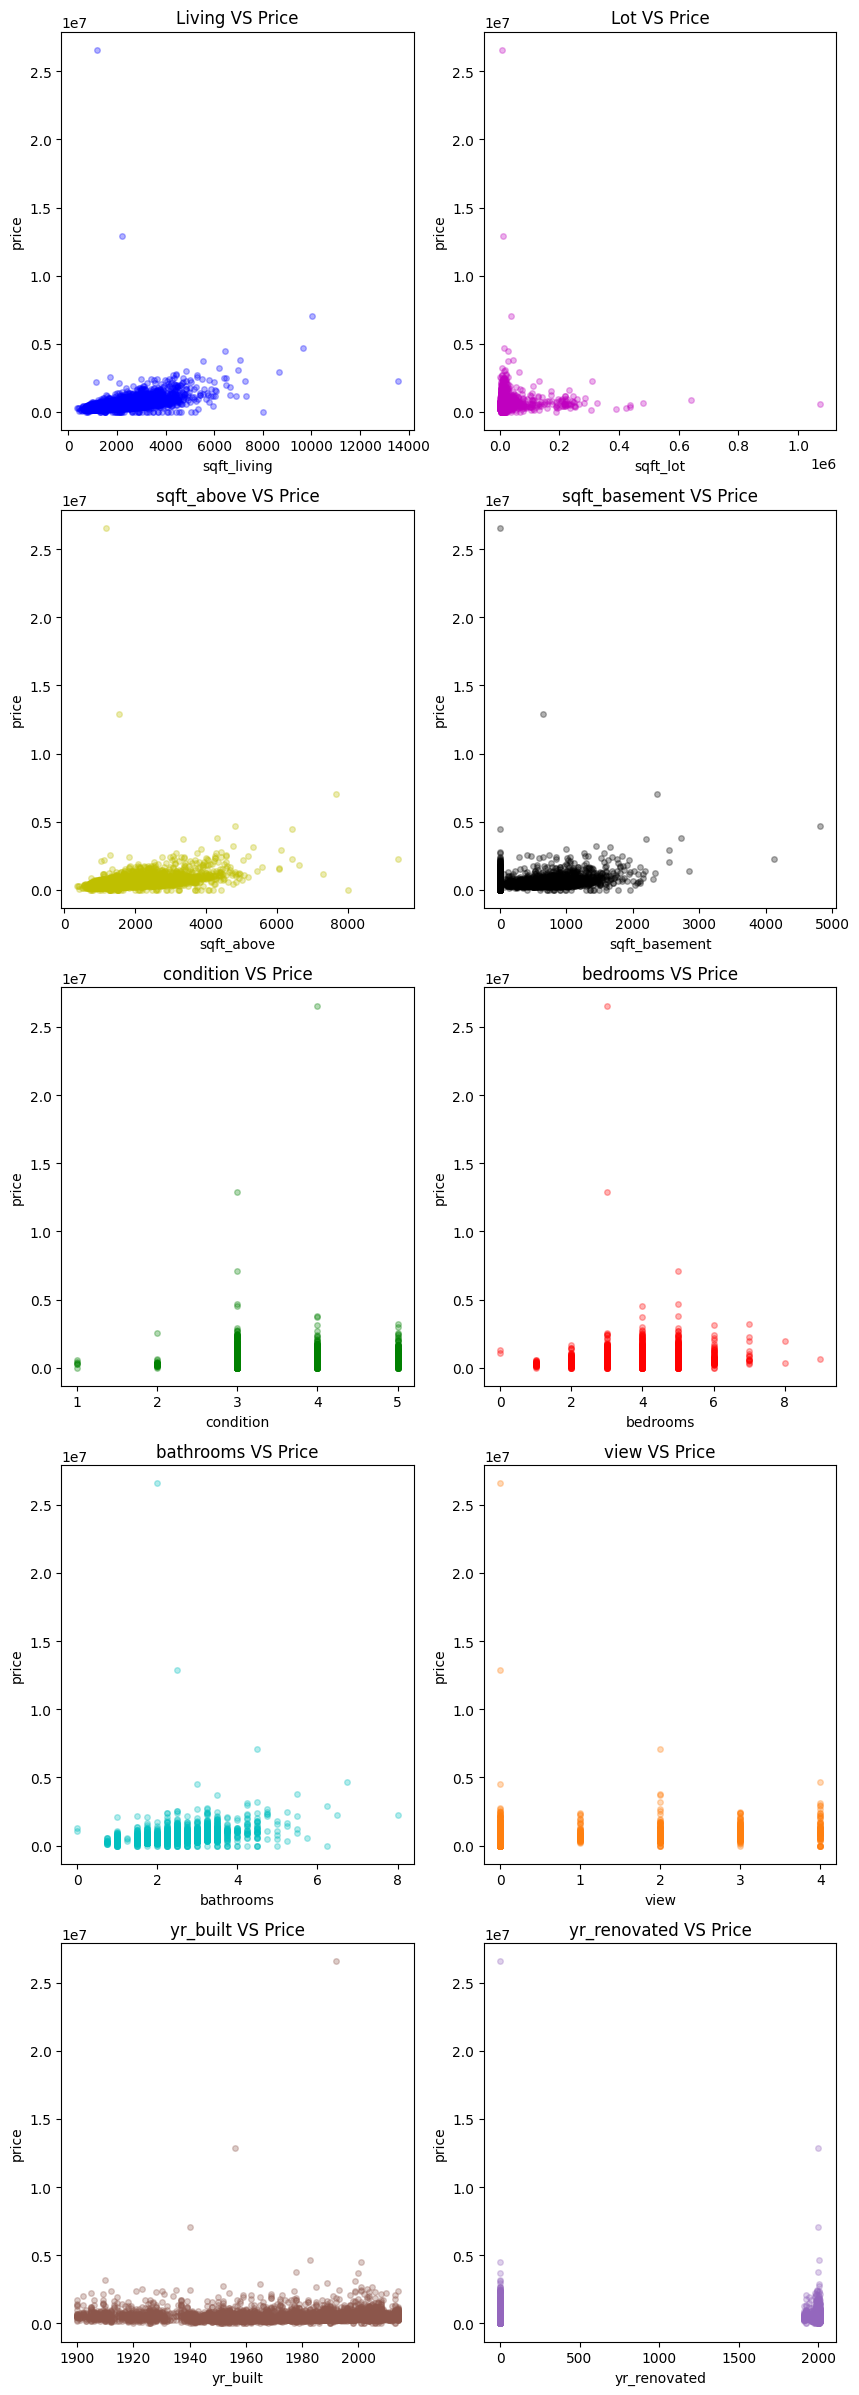

In [149]:
fig , axs = plt.subplots(5, 2, figsize = (10, 30), alpha = 0.3)

axs[0, 0].plot(df['sqft_living'], df['price'], 'ob', alpha = 0.3, markersize = 4 )
axs[0, 0].set_xlabel("sqft_living")
axs[0, 0].set_ylabel("price")
axs[0, 0].set_title("Living VS Price")

axs[0, 1].plot(df['sqft_lot'], df['price'], 'om', alpha = 0.3, markersize = 4 )
axs[0, 1].set_xlabel("sqft_lot")
axs[0, 1].set_ylabel("price")
axs[0, 1].set_title("Lot VS Price")

axs[1, 0].plot(df['sqft_above'], df['price'], 'oy', alpha = 0.3, markersize = 4 )
axs[1, 0].set_xlabel("sqft_above")
axs[1, 0].set_ylabel("price")
axs[1, 0].set_title("sqft_above VS Price")

axs[1, 1].plot(df['sqft_basement'], df['price'], 'ok', alpha = 0.3, markersize = 4 )
axs[1, 1].set_xlabel("sqft_basement")
axs[1, 1].set_ylabel("price")
axs[1, 1].set_title("sqft_basement VS Price")

axs[2, 0].plot(df['condition'], df['price'], 'og', alpha = 0.3, markersize = 4 )
axs[2, 0].set_xlabel("condition")
axs[2, 0].set_ylabel("price")
axs[2, 0].set_title("condition VS Price")

axs[2, 1].plot(df['bedrooms'], df['price'], 'or', alpha = 0.3, markersize = 4 )
axs[2, 1].set_xlabel("bedrooms")
axs[2, 1].set_ylabel("price")
axs[2, 1].set_title("bedrooms VS Price")

axs[3, 0].plot(df['bathrooms'], df['price'], 'oc', alpha = 0.3, markersize = 4 )
axs[3, 0].set_xlabel("bathrooms")
axs[3, 0].set_ylabel("price")
axs[3, 0].set_title("bathrooms VS Price")

axs[3, 1].plot(df['view'], df['price'], 'o', color= '#ff7f0e' , alpha = 0.3, markersize = 4 )
axs[3, 1].set_xlabel("view")
axs[3, 1].set_ylabel("price")
axs[3, 1].set_title("view VS Price")

axs[4, 0].plot(df['yr_built'], df['price'], 'o', color= '#8c564b' , alpha = 0.3, markersize = 4 )
axs[4, 0].set_xlabel("yr_built")
axs[4, 0].set_ylabel("price")
axs[4, 0].set_title("yr_built VS Price")

axs[4, 1].plot(df['yr_renovated'], df['price'], 'o', color= '#9467bd' , alpha = 0.3, markersize = 4 )
axs[4, 1].set_xlabel("yr_renovated")
axs[4, 1].set_ylabel("price")
axs[4, 1].set_title("yr_renovated VS Price")

clearing outliers from data set :

In [150]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 3 * iqr
upper = q1 + 3 * iqr

In [151]:
df_filtered = df[(df['price'] <= upper) & (df['price'] >= lower)]

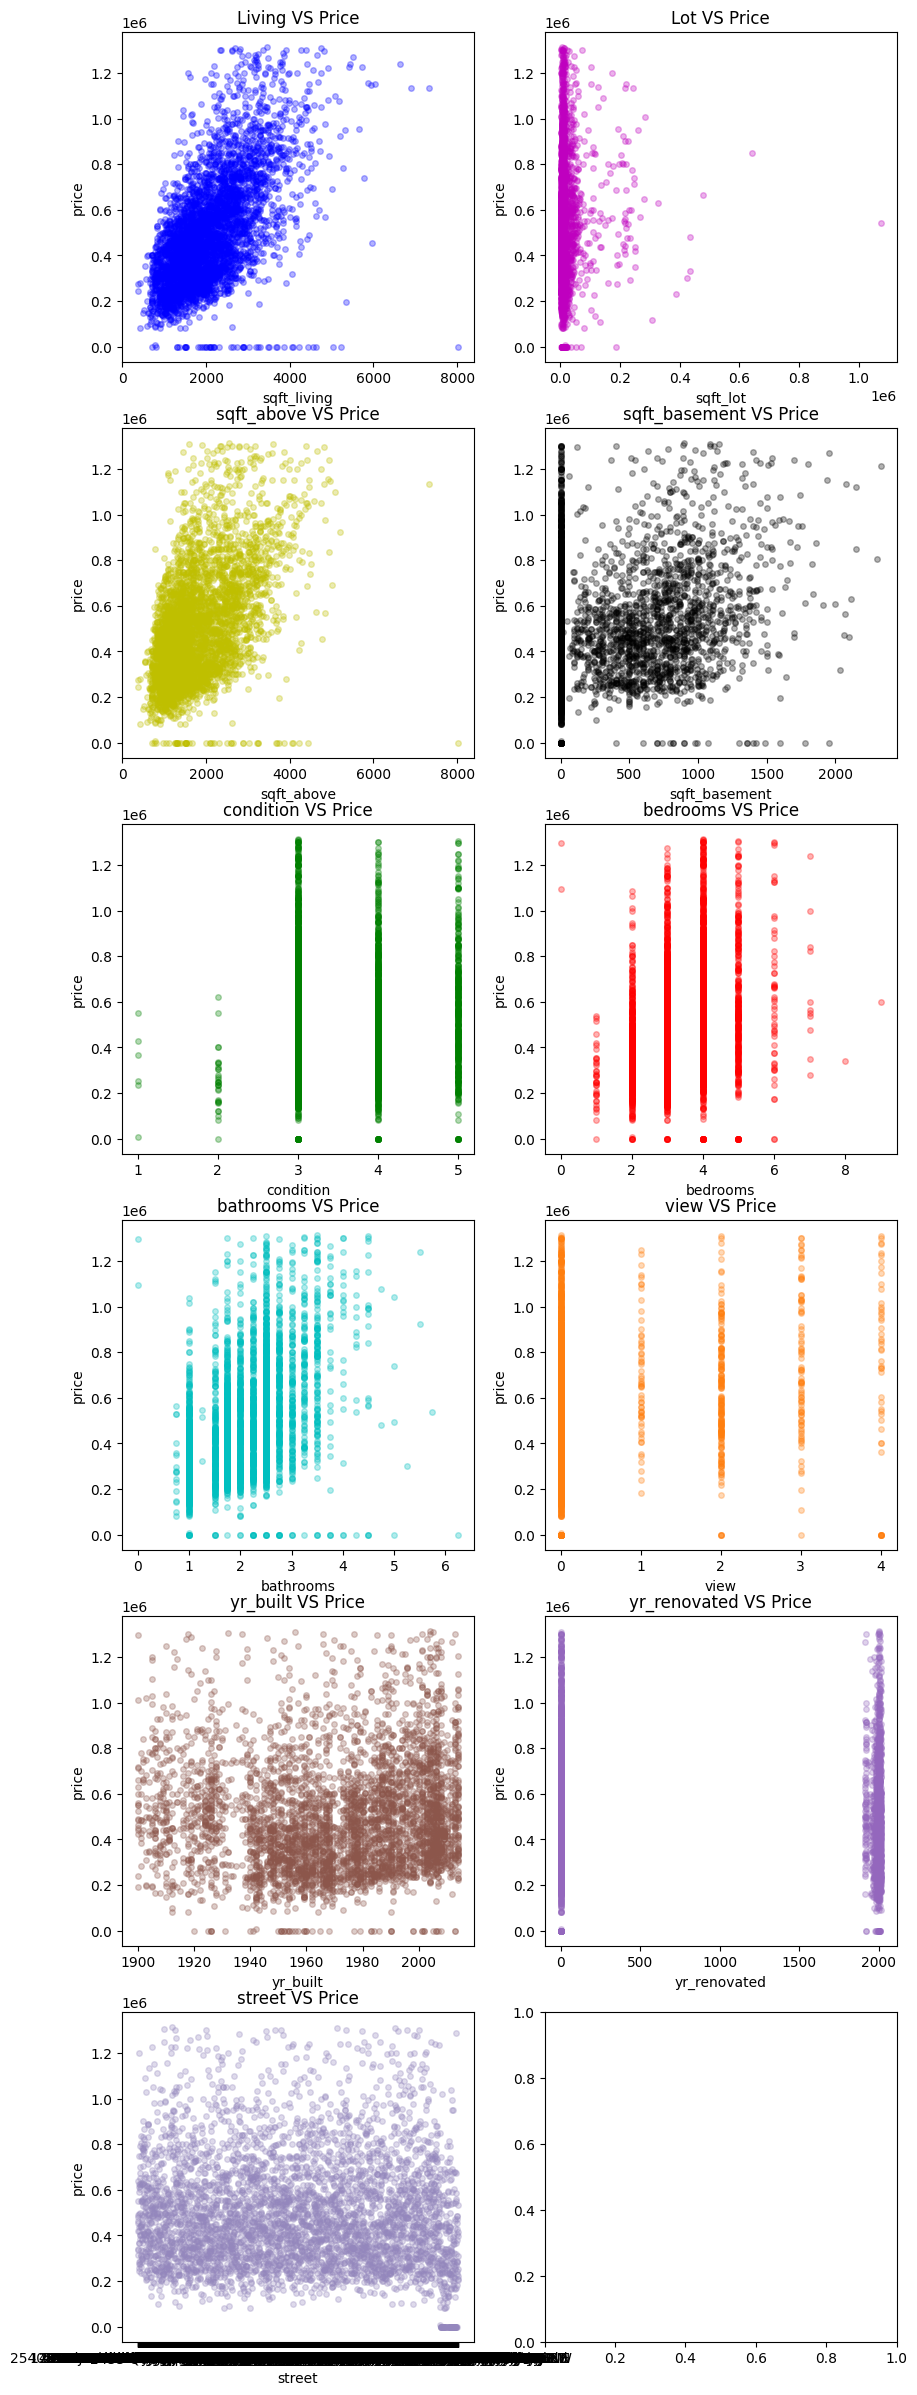

In [152]:
fig , axs = plt.subplots(6, 2, figsize = (10, 30), alpha = 0.3)

axs[0, 0].plot(df_filtered['sqft_living'], df_filtered['price'], 'ob', alpha = 0.3, markersize = 4 )
axs[0, 0].set_xlabel("sqft_living")
axs[0, 0].set_ylabel("price")
axs[0, 0].set_title("Living VS Price")

axs[0, 1].plot(df_filtered['sqft_lot'], df_filtered['price'], 'om', alpha = 0.3, markersize = 4 )
axs[0, 1].set_xlabel("sqft_lot")
axs[0, 1].set_ylabel("price")
axs[0, 1].set_title("Lot VS Price")

axs[1, 0].plot(df_filtered['sqft_above'], df_filtered['price'], 'oy', alpha = 0.3, markersize = 4 )
axs[1, 0].set_xlabel("sqft_above")
axs[1, 0].set_ylabel("price")
axs[1, 0].set_title("sqft_above VS Price")

axs[1, 1].plot(df_filtered['sqft_basement'], df_filtered['price'], 'ok', alpha = 0.3, markersize = 4 )
axs[1, 1].set_xlabel("sqft_basement")
axs[1, 1].set_ylabel("price")
axs[1, 1].set_title("sqft_basement VS Price")

axs[2, 0].plot(df_filtered['condition'], df_filtered['price'], 'og', alpha = 0.3, markersize = 4 )
axs[2, 0].set_xlabel("condition")
axs[2, 0].set_ylabel("price")
axs[2, 0].set_title("condition VS Price")

axs[2, 1].plot(df_filtered['bedrooms'], df_filtered['price'], 'or', alpha = 0.3, markersize = 4 )
axs[2, 1].set_xlabel("bedrooms")
axs[2, 1].set_ylabel("price")
axs[2, 1].set_title("bedrooms VS Price")

axs[3, 0].plot(df_filtered['bathrooms'], df_filtered['price'], 'oc', alpha = 0.3, markersize = 4 )
axs[3, 0].set_xlabel("bathrooms")
axs[3, 0].set_ylabel("price")
axs[3, 0].set_title("bathrooms VS Price")

axs[3, 1].plot(df_filtered['view'], df_filtered['price'], 'o', color= '#ff7f0e' , alpha = 0.3, markersize = 4 )
axs[3, 1].set_xlabel("view")
axs[3, 1].set_ylabel("price")
axs[3, 1].set_title("view VS Price")

axs[4, 0].plot(df_filtered['yr_built'], df_filtered['price'], 'o', color= '#8c564b' , alpha = 0.3, markersize = 4 )
axs[4, 0].set_xlabel("yr_built")
axs[4, 0].set_ylabel("price")
axs[4, 0].set_title("yr_built VS Price")

axs[4, 1].plot(df_filtered['yr_renovated'], df_filtered['price'], 'o', color= '#9467bd' , alpha = 0.3, markersize = 4 )
axs[4, 1].set_xlabel("yr_renovated")
axs[4, 1].set_ylabel("price")
axs[4, 1].set_title("yr_renovated VS Price")

axs[5, 0].plot(df_filtered['street'], df_filtered['price'], 'o', color= '#9487bd' , alpha = 0.3, markersize = 4 )
axs[5, 0].set_xlabel("street")
axs[5, 0].set_ylabel("price")
axs[5, 0].set_title("street VS Price")

plt.show()

In [153]:
print(len(df))
print(len(df_filtered))

4600
4437


### Hand made class :)))))))

In [154]:
class Multiple_linearRegression:
  
  def __init__(self, bias, lr, epoch, nf):
    self.w = np.random.rand(nf) * 0.01
    self.bias = bias
    self.lr = lr
    self.epoch = epoch
    self.loss = []
    
  def MSE_loss(self, x, y):
    y_hat = self.predict(x)
    return np.mean((y - y_hat)**2)
  
  def predict(self, x):

    y_hat = np.dot(x , self.w) + self.bias
    return y_hat
   
    
    
  
  def grad(self, x, y):
    n = len(x)
    dw = 2/n *np.dot(x.T , (self.predict(x) - y ))
    db = 2/n *np.sum(self.predict(x) - y)
    return dw, db
  
  def fit(self, x, y):
    for i in range(self.epoch):
      dw, db = self.grad(x, y)
      self.w = self.w - self.lr * dw
      self.bias = self.bias - self.lr * db
      lo = self.MSE_loss(x, y)
      self.loss.append(lo)
      
      
  def score(self, X, y):
        
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2
    
  def plot_loss(self):
       
        plt.figure(figsize=(10, 5))
        plt.plot(self.loss)
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title('Training Loss over Time')
        plt.yscale('log')
        plt.grid(True)
        plt.show()    

In [155]:
msk = np.random.rand(len(df_filtered)) < 0.8

train = df_filtered[msk]
test = df_filtered[~msk]

print(f"persent of train data : {len(train)/len(df_filtered) * 100:0.2f}%")
print(f"persent of test data : {len(test)/len(df_filtered) * 100:0.2f}%")

persent of train data : 80.41%
persent of test data : 19.59%


In [156]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [157]:
street_mapping = {street : i for i , street in enumerate(df_filtered['street'].unique())}
df_filtered['street_encoded'] = df_filtered['street'].map(street_mapping)
df_filtered.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,street_encoded
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,0
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,1
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,2
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,3
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA,4


In [160]:

def max_normalize(X):

    X_max = np.max(X, axis=0)
    X_max[X_max == 0] = 1
    return X / X_max, X_max


features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'view', 'street_encoded']
X = df_filtered[features].values
y = df_filtered['price'].values

X_normalized, X_max = max_normalize(X)


y_max = np.max(y)
y_normalized = y / y_max

print("Befor Normalize :")
print(f"X range: [{X.min():.2f}, {X.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

print("After Normalize :")
print(f"X range: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")
print(f"y range: [{y_normalized.min():.2f}, {y_normalized.max():.2f}]")

Befor Normalize :
X range: [0.00, 1074218.00]
y range: [0.00, 1315000.00]
After Normalize :
X range: [0.00, 1.00]
y range: [0.00, 1.00]


In [164]:


model = Multiple_linearRegression(0, 0.001, 500, 7)
model.fit(X_normalized, y_normalized)

for i in range(len(model.w)):
  print(f"Final w for Model {i+1}: {model.w[i]:.3f}")
print(f"Final Bias : {model.bias}")
print(f"Final Loss : {model.loss[-1]:.3f}")  

Final w for Model 1: 0.049
Final w for Model 2: 0.007
Final w for Model 3: 0.041
Final w for Model 4: 0.026
Final w for Model 5: 0.142
Final w for Model 6: 0.016
Final w for Model 7: 0.070
Final Bias : 0.14190322650806178
Final Loss : 0.033


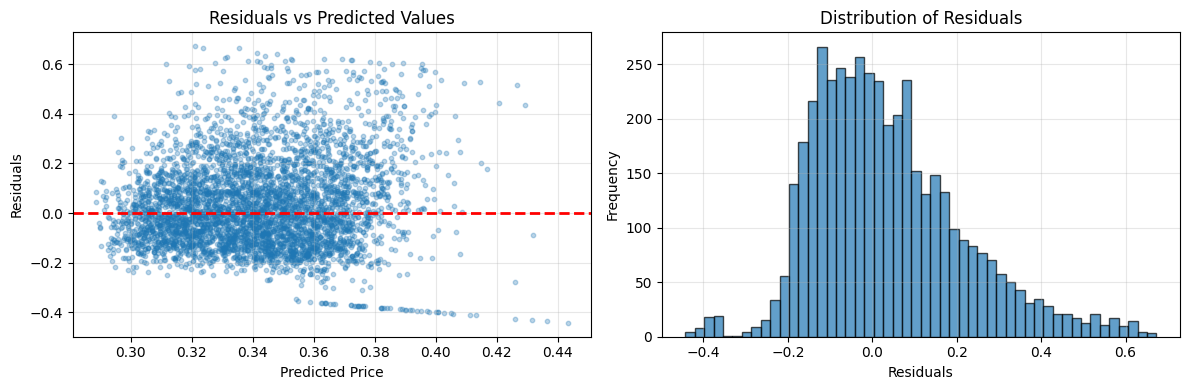

=== Residuals Statistics ===
Mean: 0.034705
Std: 0.177937
Min: -0.443160
Max: 0.673025


In [ ]:

y_pred = model.predict(X_normalized)
residuals = y_normalized - y_pred

plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("=== Residuals Statistics ===")
print(f"Mean: {np.mean(residuals):.6f}")
print(f"Std: {np.std(residuals):.6f}")
print(f"Min: {np.min(residuals):.6f}")
print(f"Max: {np.max(residuals):.6f}")